# Predicting Bike Sharing Demand Using Machine Learning and Temporal Features
**Author:** Thammishetti Venkat Sai Prathap  
**Programme:** MSc Data Science — University of Hertfordshire  

**Dataset:** UCI Bike Sharing Dataset (`hour.csv`) — hourly bike rental counts for 2011–2012  
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)

---
## Project Overview
This notebook predicts hourly bike rental demand using three approaches:
- **Random Forest Regressor** — ensemble tree-based model
- **XGBoost Regressor** — gradient boosting with lag features
- **SARIMAX** — statistical time-series model

Key techniques used: cyclical feature encoding (sin/cos), lag features, time-based train-test splitting.


## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from xgboost import XGBRegressor
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

## 2. Dataset Loading
The hourly log from Capital Bikeshare, Washington D.C., spans **17,379 records** across 2011–2012.  
Prediction target: `cnt` — combined casual and registered rentals per hour.

In [2]:
bsd = pd.read_csv("hour.csv")

print(f"Dimensions  : {bsd.shape[0]:,} rows × {bsd.shape[1]} columns")
print(f"Time window : {bsd['dteday'].min()}  →  {bsd['dteday'].max()}")
bsd.head(3)

Dimensions  : 17,379 rows × 17 columns
Time window : 2011-01-01  →  2012-12-31


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


## 3. Dataset Exploration

In [3]:
print("=== Column Schema ===")
bsd.info()
print()
print("=== Data Types ===")
print(bsd.dtypes)

=== Column Schema ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

=== Data Types ===
instant

In [4]:
print("=== Feature List ===")
print(bsd.columns.tolist())
print()
print("=== Descriptive Summary ===")
bsd.describe().round(3)

=== Feature List ===
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

=== Descriptive Summary ===


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,8690.000,2.502,0.503,6.538,11.547,0.029,3.004,0.683,1.425,0.497,0.476,0.627,0.190,35.676,153.787,189.463
std,5017.029,1.107,0.500,3.439,6.914,0.167,2.006,0.465,0.639,0.193,0.172,0.193,0.122,49.305,151.357,181.388
min,1.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.020,0.000,0.000,0.000,0.000,0.000,1.000
25%,4345.500,2.000,0.000,4.000,6.000,0.000,1.000,0.000,1.000,0.340,0.333,0.480,0.104,4.000,34.000,40.000
50%,8690.000,3.000,1.000,7.000,12.000,0.000,3.000,1.000,1.000,0.500,0.485,0.630,0.194,17.000,115.000,142.000
75%,13034.500,3.000,1.000,10.000,18.000,0.000,5.000,1.000,2.000,0.660,0.621,0.780,0.254,48.000,220.000,281.000
max,17379.000,4.000,1.000,12.000,23.000,1.000,6.000,1.000,4.000,1.000,1.000,1.000,0.851,367.000,886.000,977.000


In [5]:
print("=== Missing Values ===")
print(bsd.isnull().sum())
print()
print("=== Duplicate Row Count ===")
print(bsd.duplicated().sum())

=== Missing Values ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Duplicate Row Count ===
0


In [6]:
print("=== Rental Count (cnt) Profile ===")
bsd['cnt'].describe()

=== Rental Count (cnt) Profile ===


,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


## 4. Exploratory Data Analysis (EDA)
### 4.1 Rental Count Distribution
The target variable is right-skewed — most hours record moderate demand with rare high-count spikes tied to commuter peak periods.

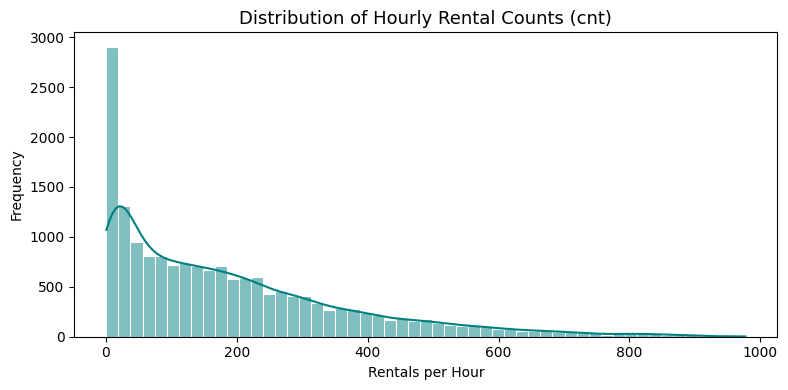

In [8]:
fig_hist,ax_hist = plt.subplots(figsize=(8, 4))
sns.histplot(bsd['cnt'], kde=True, ax=ax_hist, color='teal', edgecolor='white')
ax_hist.set_title('Distribution of Hourly Rental Counts (cnt)', fontsize=13)
ax_hist.set_xlabel('Rentals per Hour')
ax_hist.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### 4.2 Categorical Variable Frequency Distributions
Balanced seasonal and weekday counts confirm that observed demand differences across categories reflect genuine behavioural patterns, not sampling bias.

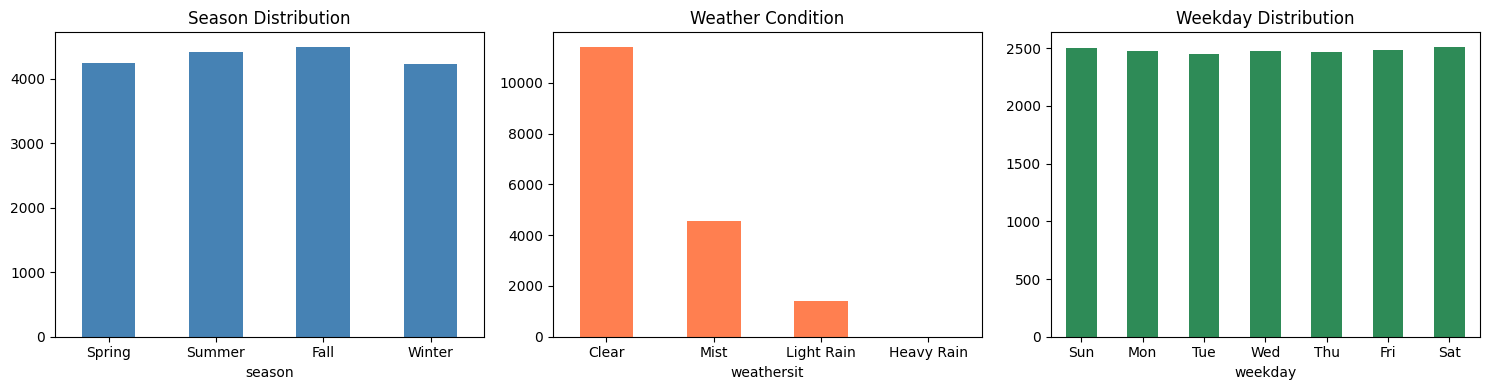

In [ ]:
fig_cat, ax_cat = plt.subplots(1, 3, figsize=(15, 4))

bsd['season'].value_counts().sort_index().plot(
    kind='bar', ax=ax_cat[0], color='steelblue', title='Season Distribution')
ax_cat[0].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'], rotation=0)

bsd['weathersit'].value_counts().sort_index().plot(
    kind='bar', ax=ax_cat[1], color='coral', title='Weather Condition')
ax_cat[1].set_xticklabels(['Clear', 'Mist', 'Light Rain', 'Heavy Rain'], rotation=0)

bsd['weekday'].value_counts().sort_index().plot(
    kind='bar', ax=ax_cat[2], color='seagreen', title='Weekday Distribution')
ax_cat[2].set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'], rotation=0)

plt.tight_layout()
plt.show()

### 4.3 Pairwise Feature Correlation
Temperature shows the strongest positive link with `cnt` (r ≈ 0.40).  
Humidity has a moderate negative relationship (r ≈ −0.32).  
`temp` and `atemp` are nearly identical (r ≈ 0.99) but both retained since tree-based models are unaffected by multicollinearity.

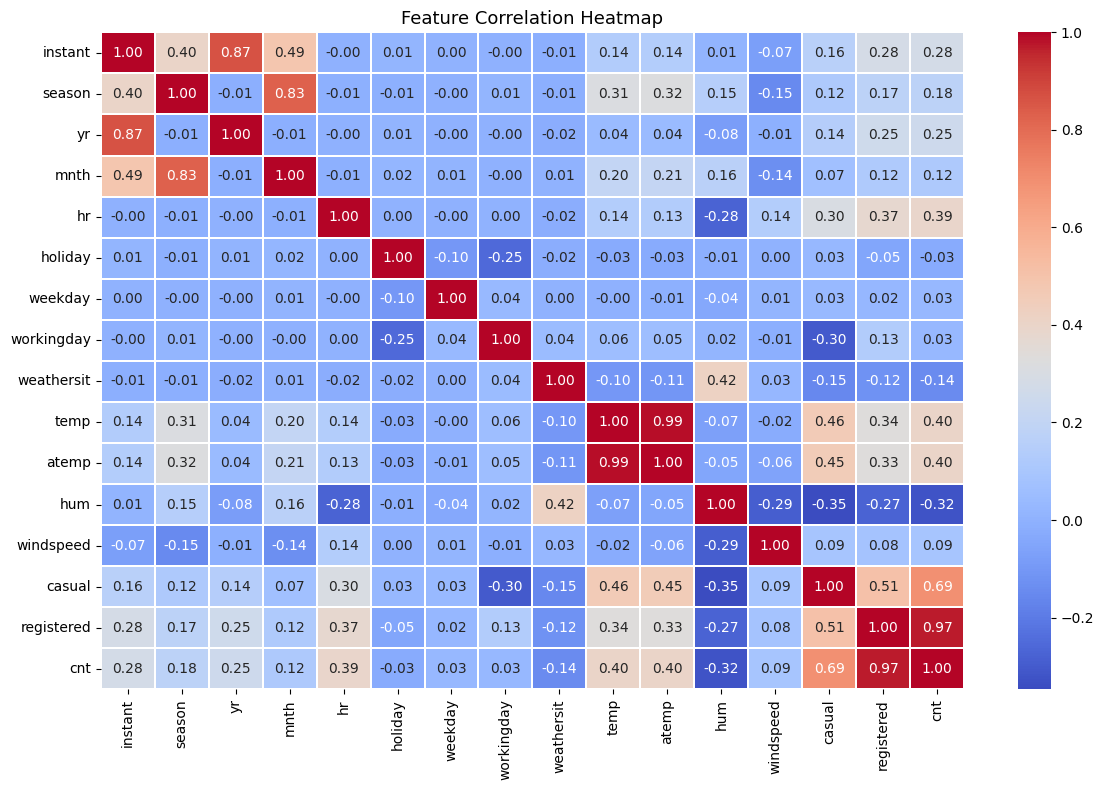

In [ ]:
corr_matrix = bsd.drop('dteday', axis=1).corr()

fig_corr, ax_corr = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.3, ax=ax_corr)
ax_corr.set_title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()

### 4.4 Meteorological vs Demand Scatter Plots
Temperature–demand relationship is nonlinear (peaks at 0.4–0.7 normalised temp).  
Wind speed shows a weak, diffuse negative association with rental volume.

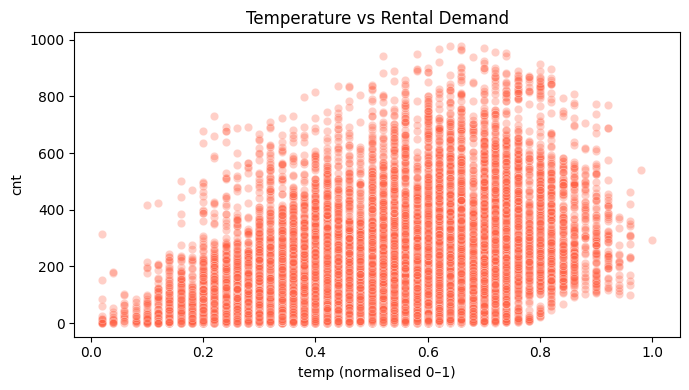

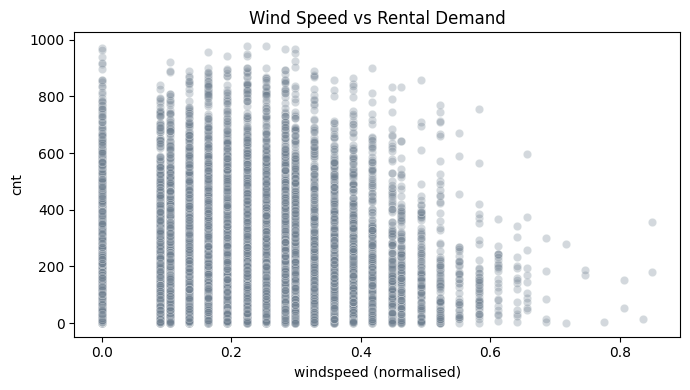

In [ ]:
fig_temp, ax_temp = plt.subplots(figsize=(7, 4))
sns.scatterplot(x='temp', y='cnt', data=bsd, alpha=0.3,
                ax=ax_temp, color='tomato')
ax_temp.set_title("Temperature vs Rental Demand")
ax_temp.set_xlabel("temp (normalised 0–1)")
ax_temp.set_ylabel("cnt")
plt.tight_layout()
plt.show()

fig_wind, ax_wind = plt.subplots(figsize=(7, 4))
sns.scatterplot(x='windspeed', y='cnt', data=bsd, alpha=0.3,
                ax=ax_wind, color='slategray')
ax_wind.set_title("Wind Speed vs Rental Demand")
ax_wind.set_xlabel("windspeed (normalised)")
ax_wind.set_ylabel("cnt")
plt.tight_layout()
plt.show()

### 4.5 Temporal Demand Patterns
- **Hour of day**: bimodal commuter signature — morning peak ∼08:00, larger evening peak ∼17:00–18:00, near-zero overnight  
- **Month**: summer months (Jun–Sep) drive peak usage; winter months the lowest  
- **Year**: hourly average rose from ∼145 (2011) to ∼234 (2012), validating `yr` as a predictor

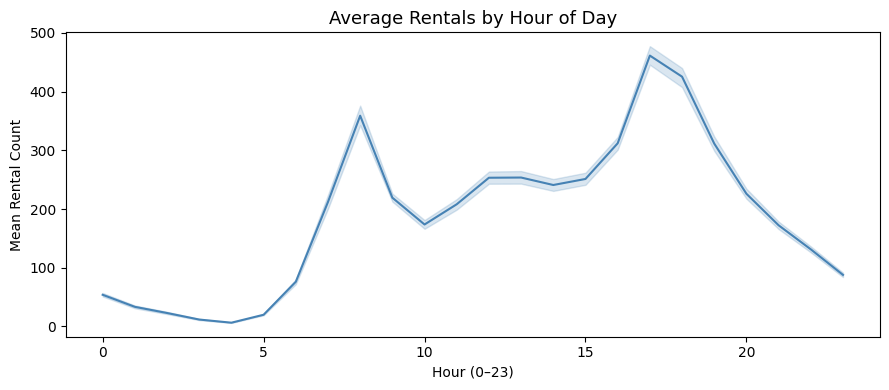

In [ ]:
fig_hr, ax_hr = plt.subplots(figsize=(9, 4))
sns.lineplot(x='hr', y='cnt', data=bsd, estimator='mean',
             color='steelblue', ax=ax_hr)
ax_hr.set_title("Average Rentals by Hour of Day", fontsize=13)
ax_hr.set_xlabel("Hour (0–23)")
ax_hr.set_ylabel("Mean Rental Count")
plt.tight_layout()
plt.show()

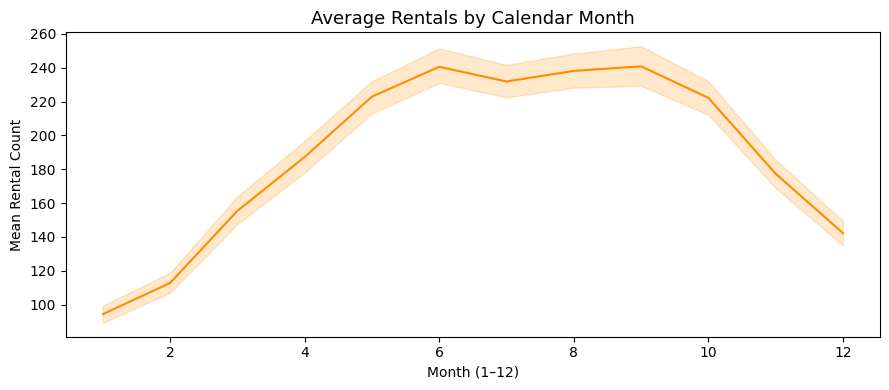

In [ ]:
fig_mo, ax_mo = plt.subplots(figsize=(9, 4))
sns.lineplot(x='mnth', y='cnt', data=bsd, estimator='mean',
             color='darkorange', ax=ax_mo)
ax_mo.set_title("Average Rentals by Calendar Month", fontsize=13)
ax_mo.set_xlabel("Month (1–12)")
ax_mo.set_ylabel("Mean Rental Count")
plt.tight_layout()
plt.show()

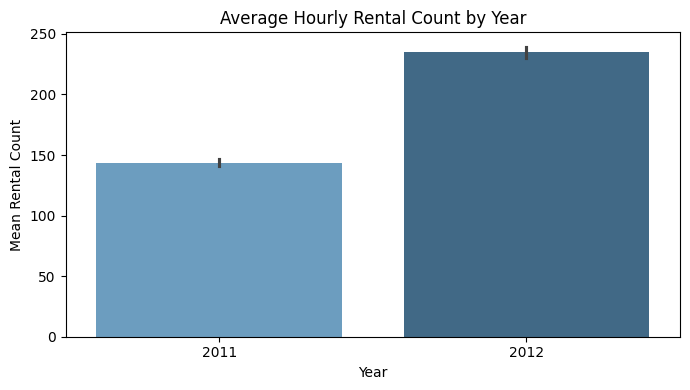

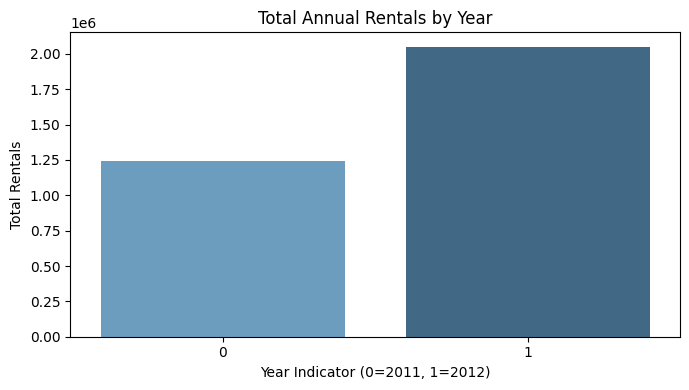

In [ ]:
bsd["year_label"] = bsd["yr"].map({0: "2011", 1: "2012"})

# First plot: Average Hourly Rental Count by Year
fig_yr_avg, ax_yr_avg = plt.subplots(figsize=(7, 4))
sns.barplot(x="year_label", y="cnt", data=bsd,
            estimator="mean", hue="year_label", palette="Blues_d", ax=ax_yr_avg, legend=False)
ax_yr_avg.set_title("Average Hourly Rental Count by Year")
ax_yr_avg.set_xlabel("Year")
ax_yr_avg.set_ylabel("Mean Rental Count")
plt.tight_layout()
plt.show()

# Second plot: Total Annual Rentals by Year
annual = bsd.groupby("yr")["cnt"].sum().reset_index()
fig_yr_total, ax_yr_total = plt.subplots(figsize=(7, 4))
sns.barplot(x="yr", y="cnt", data=annual, hue="yr", palette="Blues_d", ax=ax_yr_total, legend=False)
ax_yr_total.set_title("Total Annual Rentals by Year")
ax_yr_total.set_xlabel("Year Indicator (0=2011, 1=2012)")
ax_yr_total.set_ylabel("Total Rentals")
plt.tight_layout()
plt.show()

### 4.6 Predictor Spread and Outlier Inspection
Boxplot confirms `hr` and `mnth` have the widest natural range.  
No extreme outliers were identified in any predictor variable.

/tmp/ipykernel_6892/3299527262.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(predictor_cols, rotation=90)


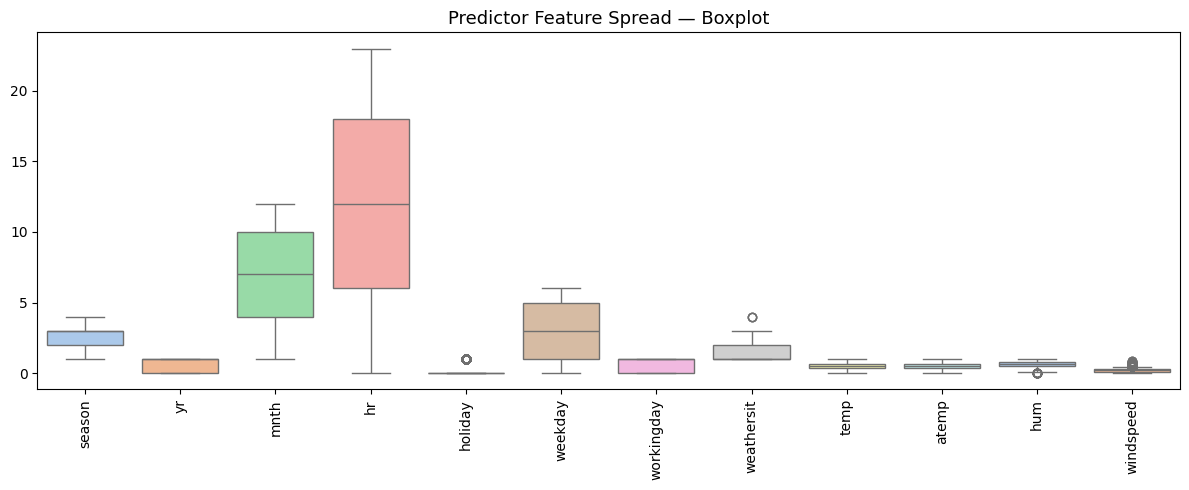

In [ ]:
bsd.drop(columns=['instant'], inplace=True, errors='ignore')

predictor_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
                  'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

fig_box, ax_box = plt.subplots(figsize=(12, 5))
sns.boxplot(data=bsd[predictor_cols], palette="pastel", ax=ax_box)
ax_box.set_xticklabels(predictor_cols, rotation=90)
ax_box.set_title("Predictor Feature Spread — Boxplot", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# IQR fence-based outlier count on the target variable
q1_cnt = bsd['cnt'].quantile(0.25)
q3_cnt = bsd['cnt'].quantile(0.75)
iqr_cnt = q3_cnt - q1_cnt

lower_bound = q1_cnt - 1.5 * iqr_cnt
upper_bound = q3_cnt + 1.5 * iqr_cnt
n_outliers  = ((bsd['cnt'] < lower_bound) | (bsd['cnt'] > upper_bound)).sum()

print(f"IQR lower bound : {lower_bound:.1f}")
print(f"IQR upper bound : {upper_bound:.1f}")
print(f"Outlier records : {n_outliers}  ({n_outliers / len(bsd) * 100:.1f}% of dataset)")

# Sort dataset into strict chronological order before any modelling step
bsd["dteday"] = pd.to_datetime(bsd["dteday"])
bsd = bsd.sort_values(["dteday", "hr"]).reset_index(drop=True)
print(f"Records in chronological order. Final shape: {bsd.shape}")

IQR lower bound : -321.5
IQR upper bound : 642.5
Outlier records : 505  (2.9% of dataset)
Records in chronological order. Final shape: (17379, 17)


## 6. Random Forest — Baseline Model
**Feature engineering applied:**
- Sin/cos cyclical encoding for `hr` (period=24) and `mnth` (period=12) — model recognises that 23:00 is adjacent to 00:00  
- One-hot encoding for `season`, `weathersit`, `weekday` (`drop_first` avoids redundancy)  
- Strict chronological 80/20 train-test split — training on earlier data, testing on later data

In [ ]:
rf_data = bsd.copy()

rf_data.drop(columns=["casual", "registered", "instant"], errors="ignore", inplace=True)

rf_data["hr_sin"]   = np.sin(2 * np.pi * rf_data["hr"]   / 24)
rf_data["hr_cos"]   = np.cos(2 * np.pi * rf_data["hr"]   / 24)
rf_data["mnth_sin"] = np.sin(2 * np.pi * rf_data["mnth"] / 12)
rf_data["mnth_cos"] = np.cos(2 * np.pi * rf_data["mnth"] / 12)

rf_data = pd.get_dummies(rf_data,
                         columns=["season", "weathersit", "weekday"],
                         drop_first=True)

rf_data = rf_data.sort_values(["dteday", "hr"]).reset_index(drop=True)
cutoff_rf = int(len(rf_data) * 0.8)

rf_train = rf_data.iloc[:cutoff_rf]
rf_test  = rf_data.iloc[cutoff_rf:]

X_rf_tr = rf_train.drop(columns=["cnt", "dteday"])
y_rf_tr = rf_train["cnt"]
X_rf_te = rf_test.drop(columns=["cnt", "dteday"])
y_rf_te = rf_test["cnt"]

forest_base = RandomForestRegressor(random_state=42)
forest_base.fit(X_rf_tr, y_rf_tr)
yhat_rf_base = forest_base.predict(X_rf_te)

rf_b_rmse = np.sqrt(mean_squared_error(y_rf_te, yhat_rf_base))
rf_b_mae  = mean_absolute_error(y_rf_te, yhat_rf_base)
rf_b_r2   = r2_score(y_rf_te, yhat_rf_base)
rf_b_mape = np.mean(np.abs((y_rf_te - yhat_rf_base) / np.maximum(y_rf_te, 1))) * 100

print("=== Random Forest Baseline — Evaluation (80/20 Chronological Split) ===")
print(f"RMSE : {rf_b_rmse:.2f}")
print(f"MAE  : {rf_b_mae:.2f}")
print(f"R²   : {rf_b_r2:.4f}")
print(f"MAPE : {rf_b_mape:.2f}%")

=== Random Forest Baseline — Evaluation (80/20 Chronological Split) ===
RMSE : 81.33
MAE  : 53.93
R²   : 0.8639
MAPE : 35.71%


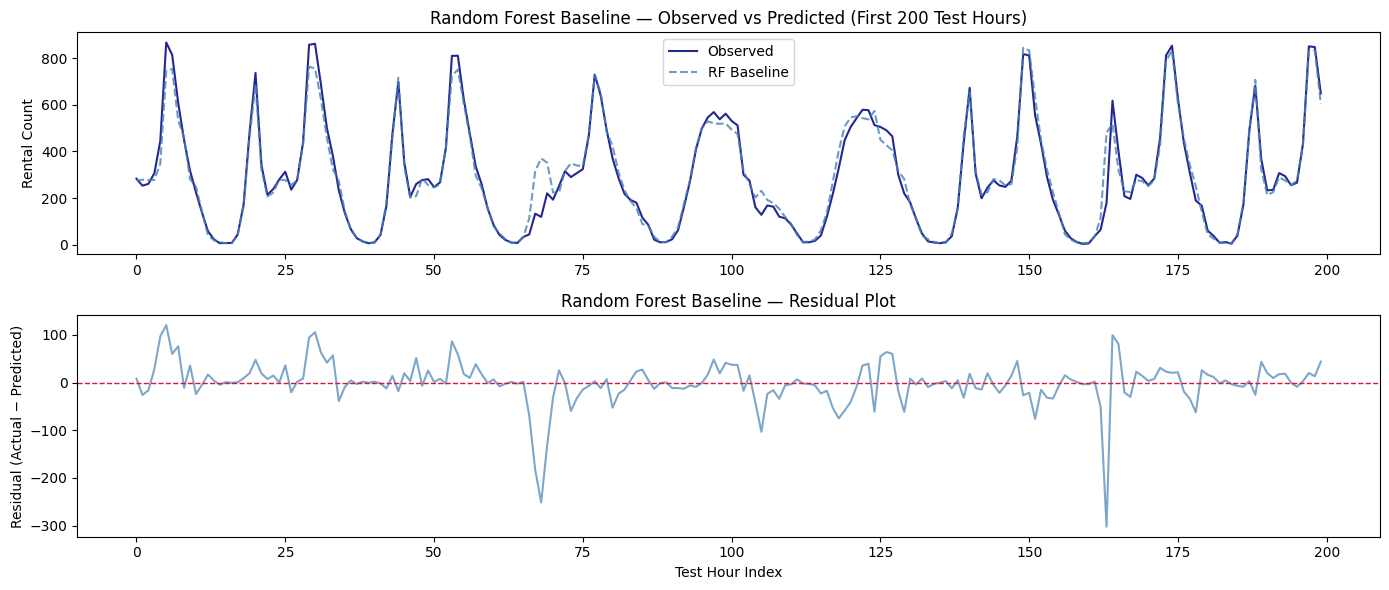

In [ ]:
fig_rf, ax_rf = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

ax_rf[0].plot(y_rf_te.values[:200], label="Observed", alpha=0.85, color='navy')
ax_rf[0].plot(yhat_rf_base[:200],   label="RF Baseline", alpha=0.8,
              color='steelblue', linestyle='--')
ax_rf[0].set_title("Random Forest Baseline — Observed vs Predicted (First 200 Test Hours)")
ax_rf[0].set_ylabel("Rental Count")
ax_rf[0].legend()

err_rf = y_rf_te.values - yhat_rf_base
ax_rf[1].plot(err_rf[:200], color="steelblue", alpha=0.7)
ax_rf[1].axhline(0, color="crimson", linestyle="--", linewidth=1)
ax_rf[1].set_title("Random Forest Baseline — Residual Plot")
ax_rf[1].set_xlabel("Test Hour Index")
ax_rf[1].set_ylabel("Residual (Actual − Predicted)")

plt.tight_layout()
plt.show()

## 7. XGBoost — Baseline Model
XGBoost receives three autocorrelation lag features not given to Random Forest:
- `lag_1` — rentals from the immediately preceding hour  
- `lag_24` — rentals from the equivalent hour on the prior day  
- `lag_168` — rentals from the equivalent hour one week earlier  

These directly capture the strong temporal autocorrelation in rental demand confirmed by the ACF/PACF analysis (Section 8).

In [ ]:
xgb_data = bsd.copy()

xgb_data["ts"] = xgb_data["dteday"] + pd.to_timedelta(xgb_data["hr"], unit="h")
xgb_data = xgb_data.sort_values("ts").reset_index(drop=True)

xgb_data.drop(columns=["casual", "registered", "instant", "year_label"],
              errors="ignore", inplace=True)

xgb_data["lag_1"]   = xgb_data["cnt"].shift(1)
xgb_data["lag_24"]  = xgb_data["cnt"].shift(24)
xgb_data["lag_168"] = xgb_data["cnt"].shift(168)

xgb_data.dropna(inplace=True)
xgb_data.reset_index(drop=True, inplace=True)

xgb_data["hr_sin"] = np.sin(2 * np.pi * xgb_data["hr"] / 24)
xgb_data["hr_cos"] = np.cos(2 * np.pi * xgb_data["hr"] / 24)

xgb_data = pd.get_dummies(xgb_data,
                           columns=["season", "weathersit", "weekday"],
                           drop_first=True)

cutoff_xgb = int(len(xgb_data) * 0.8)
xgb_train  = xgb_data.iloc[:cutoff_xgb]
xgb_test   = xgb_data.iloc[cutoff_xgb:]

X_xgb_tr = xgb_train.drop(columns=["cnt", "dteday", "ts"])
y_xgb_tr = xgb_train["cnt"]
X_xgb_te = xgb_test.drop(columns=["cnt", "dteday", "ts"])
y_xgb_te = xgb_test["cnt"]

boost_base = XGBRegressor(
    n_estimators=800, learning_rate=0.05,
    max_depth=7, subsample=0.8, colsample_bytree=0.8,
    random_state=42, objective="reg:squarederror"
)

boost_base.fit(X_xgb_tr, y_xgb_tr)
yhat_xgb_base = boost_base.predict(X_xgb_te)

xgb_b_rmse = np.sqrt(mean_squared_error(y_xgb_te, yhat_xgb_base))
xgb_b_mae  = mean_absolute_error(y_xgb_te, yhat_xgb_base)
xgb_b_r2   = r2_score(y_xgb_te, yhat_xgb_base)
xgb_b_mape = np.mean(np.abs((y_xgb_te - yhat_xgb_base) / np.maximum(y_xgb_te, 1))) * 100

print("=== XGBoost Baseline — Evaluation (80/20 Chronological Split) ===")
print(f"RMSE : {xgb_b_rmse:.2f}")
print(f"MAE  : {xgb_b_mae:.2f}")
print(f"R²   : {xgb_b_r2:.4f}")
print(f"MAPE : {xgb_b_mape:.2f}%")

=== XGBoost Baseline — Evaluation (80/20 Chronological Split) ===
RMSE : 46.98
MAE  : 29.10
R²   : 0.9543
MAPE : 25.47%


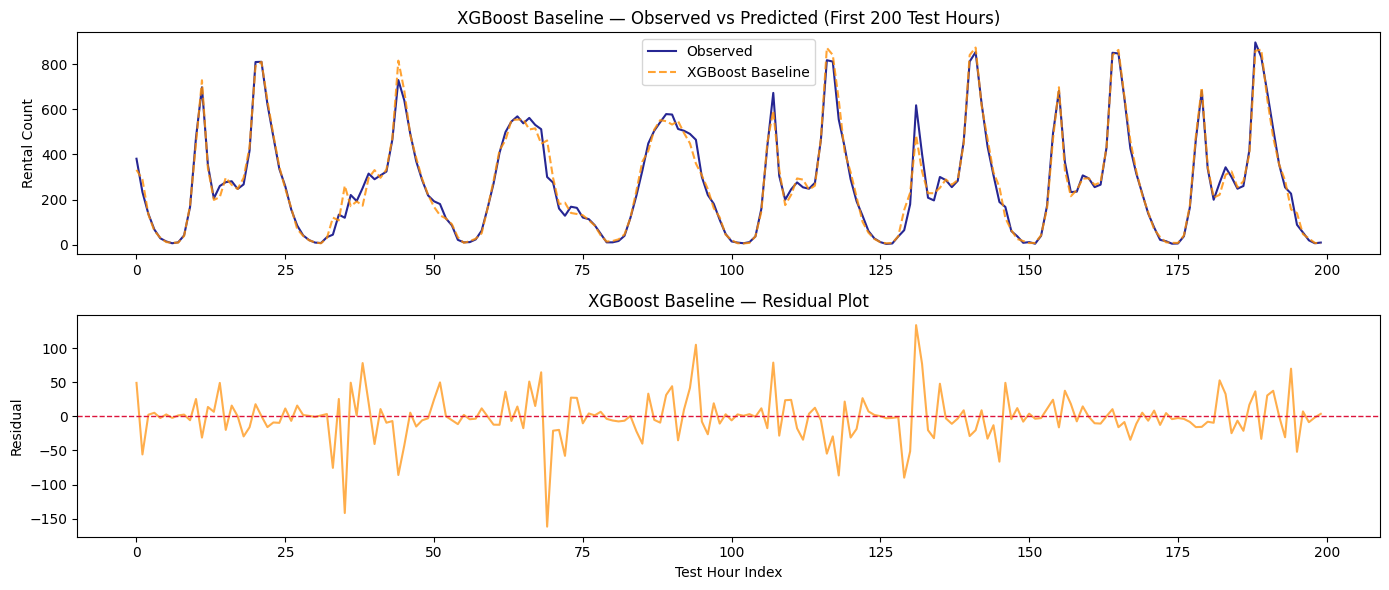

In [ ]:
fig_xgb, ax_xgb = plt.subplots(2, 1, figsize=(14, 6))

ax_xgb[0].plot(y_xgb_te.values[:200], label="Observed", alpha=0.85, color='navy')
ax_xgb[0].plot(yhat_xgb_base[:200],   label="XGBoost Baseline", alpha=0.8,
               color='darkorange', linestyle='--')
ax_xgb[0].set_title("XGBoost Baseline — Observed vs Predicted (First 200 Test Hours)")
ax_xgb[0].set_ylabel("Rental Count")
ax_xgb[0].legend()

err_xgb = y_xgb_te.values - yhat_xgb_base
ax_xgb[1].plot(err_xgb[:200], color="darkorange", alpha=0.7)
ax_xgb[1].axhline(0, color="crimson", linestyle="--", linewidth=1)
ax_xgb[1].set_title("XGBoost Baseline — Residual Plot")
ax_xgb[1].set_xlabel("Test Hour Index")
ax_xgb[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

## 8. Stationarity & Autocorrelation Diagnostics (SARIMAX Pre-check)
Two checks are run before fitting SARIMAX:
1. **Augmented Dickey-Fuller (ADF) test** — verifies stationarity (p < 0.05 → no differencing needed)  
2. **ACF / PACF plots** — guide selection of AR order `p` and MA order `q`

ADF Statistic : -6.3029
p-value       : 0.000000
Verdict       : Stationary ✓ — no differencing required


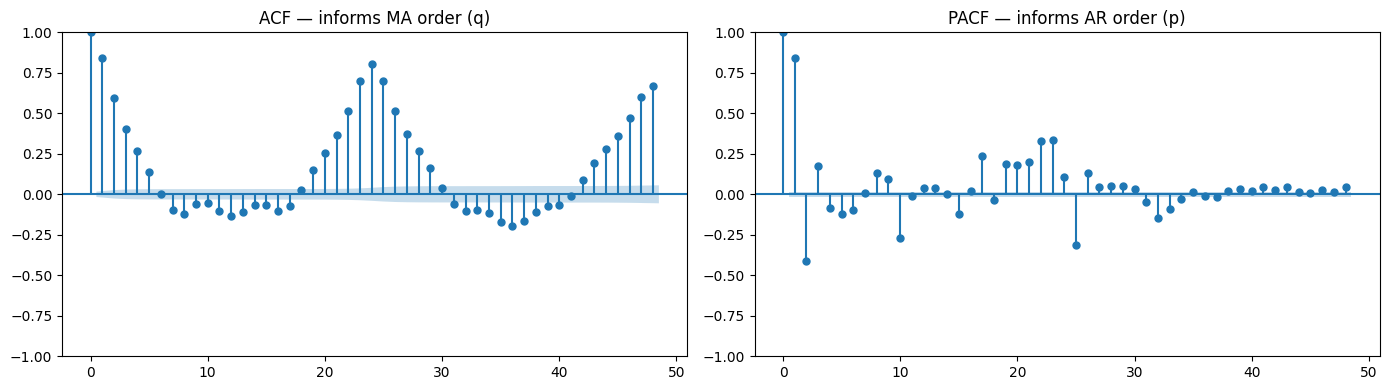

In [ ]:
adf_out = adfuller(y_xgb_tr)
print(f"ADF Statistic : {adf_out[0]:.4f}")
print(f"p-value       : {adf_out[1]:.6f}")
verdict = "Stationary ✓ — no differencing required" if adf_out[1] < 0.05 else "Non-stationary — differencing may be needed"
print(f"Verdict       : {verdict}")

fig_diag, ax_diag = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_xgb_tr,  lags=48, ax=ax_diag[0])
ax_diag[0].set_title("ACF — informs MA order (q)")
plot_pacf(y_xgb_tr, lags=48, ax=ax_diag[1])
ax_diag[1].set_title("PACF — informs AR order (p)")
plt.tight_layout()
plt.show()

## 9. SARIMAX — Baseline Model
Specification: `SARIMAX(1,0,1)(1,0,1)[24]`  
Exogenous regressors include cyclical time encodings and meteorological variables.  
SARIMAX serves as the classical statistical reference point against which the ML models are compared.

In [ ]:
sar_data = bsd.copy()

sar_data.drop(columns=["casual", "registered", "instant"], errors="ignore", inplace=True)

sar_data["hr_sin"]   = np.sin(2 * np.pi * sar_data["hr"]   / 24)
sar_data["hr_cos"]   = np.cos(2 * np.pi * sar_data["hr"]   / 24)
sar_data["mnth_sin"] = np.sin(2 * np.pi * sar_data["mnth"] / 12)
sar_data["mnth_cos"] = np.cos(2 * np.pi * sar_data["mnth"] / 12)

sar_data = pd.get_dummies(sar_data,
                           columns=["season", "weathersit", "weekday"],
                           drop_first=True)

sar_data = sar_data.sort_values(["dteday", "hr"]).reset_index(drop=True)

cutoff_sar = int(len(sar_data) * 0.8)
sar_train  = sar_data.iloc[:cutoff_sar]
sar_test   = sar_data.iloc[cutoff_sar:]

X_sar_tr = sar_train.drop(columns=["cnt", "dteday"]).astype(float)
y_sar_tr = sar_train["cnt"].astype(float)
X_sar_te = sar_test.drop(columns=["cnt", "dteday"]).astype(float)
y_sar_te = sar_test["cnt"].astype(float)

X_sar_tr_sm = sm.add_constant(X_sar_tr, has_constant="add")
X_sar_te_sm = sm.add_constant(X_sar_te, has_constant="add")
X_sar_te_sm = X_sar_te_sm.reindex(columns=X_sar_tr_sm.columns, fill_value=0)

sarimax_spec = sm.tsa.statespace.SARIMAX(
    y_sar_tr,
    exog=X_sar_tr_sm,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_spec.fit(disp=False)

fcast_obj   = sarimax_fit.get_forecast(steps=len(y_sar_te), exog=X_sar_te_sm)
yhat_sar    = fcast_obj.predicted_mean

sar_b_rmse = np.sqrt(mean_squared_error(y_sar_te, yhat_sar))
sar_b_mae  = mean_absolute_error(y_sar_te, yhat_sar)
sar_b_r2   = r2_score(y_sar_te, yhat_sar)
sar_b_mape = np.mean(np.abs((y_sar_te - yhat_sar) / np.maximum(y_sar_te, 1))) * 100

print("=== SARIMAX Baseline — Evaluation (80/20 Chronological Split) ===")
print(f"RMSE : {sar_b_rmse:.2f}")
print(f"MAE  : {sar_b_mae:.2f}")
print(f"R²   : {sar_b_r2:.4f}")
print(f"MAPE : {sar_b_mape:.2f}%")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== SARIMAX Baseline — Evaluation (80/20 Chronological Split) ===
RMSE : 150.64
MAE  : 117.93
R²   : 0.5332
MAPE : 305.14%


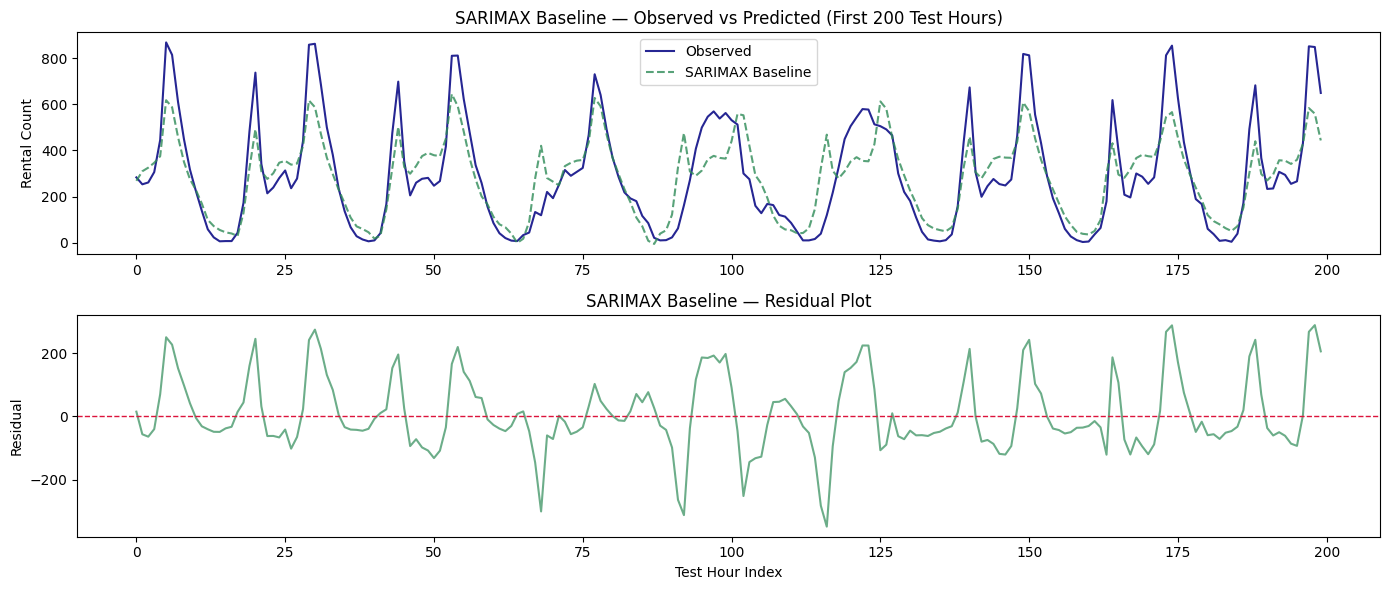

In [ ]:
yhat_sar_plot = yhat_sar.reset_index(drop=True)
y_sar_te_plot = y_sar_te.reset_index(drop=True)

fig_sar, ax_sar = plt.subplots(2, 1, figsize=(14, 6))

ax_sar[0].plot(y_sar_te_plot.values[:200], label="Observed", alpha=0.85, color='navy')
ax_sar[0].plot(yhat_sar_plot.values[:200], label="SARIMAX Baseline", alpha=0.8,
               color='seagreen', linestyle='--')
ax_sar[0].set_title("SARIMAX Baseline — Observed vs Predicted (First 200 Test Hours)")
ax_sar[0].set_ylabel("Rental Count")
ax_sar[0].legend()

err_sar = y_sar_te_plot.values - yhat_sar_plot.values
ax_sar[1].plot(err_sar[:200], color="seagreen", alpha=0.7)
ax_sar[1].axhline(0, color="crimson", linestyle="--", linewidth=1)
ax_sar[1].set_title("SARIMAX Baseline — Residual Plot")
ax_sar[1].set_xlabel("Test Hour Index")
ax_sar[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning
`RandomizedSearchCV` with `TimeSeriesSplit(n_splits=5)` is used for all ML models.  
`TimeSeriesSplit` ensures that each validation fold only contains data from periods **after** the corresponding training fold, preventing any look-ahead leakage.

### 10.1 Random Forest — Tuned

In [ ]:
rf_tune = bsd.copy()
rf_tune.drop(columns=["casual", "registered", "instant"], errors="ignore", inplace=True)

rf_tune["hr_sin"]   = np.sin(2 * np.pi * rf_tune["hr"]   / 24)
rf_tune["hr_cos"]   = np.cos(2 * np.pi * rf_tune["hr"]   / 24)
rf_tune["mnth_sin"] = np.sin(2 * np.pi * rf_tune["mnth"] / 12)
rf_tune["mnth_cos"] = np.cos(2 * np.pi * rf_tune["mnth"] / 12)

rf_tune = pd.get_dummies(rf_tune,
                          columns=["season", "weathersit", "weekday"],
                          drop_first=True)

rf_tune = rf_tune.sort_values(["dteday", "hr"]).reset_index(drop=True)

cut_rft = int(len(rf_tune) * 0.8)
rft_tr  = rf_tune.iloc[:cut_rft]
rft_te  = rf_tune.iloc[cut_rft:]

X_rft_tr = rft_tr.drop(columns=["cnt", "dteday"])
y_rft_tr = rft_tr["cnt"]
X_rft_te = rft_te.drop(columns=["cnt", "dteday"])
y_rft_te = rft_te["cnt"]

ts_cv = TimeSeriesSplit(n_splits=5)

rf_search_space = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [10, 15, 20, 25, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2", None]
}

rf_searcher = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_search_space,
    n_iter=20,
    cv=ts_cv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)
rf_searcher.fit(X_rft_tr, y_rft_tr)

best_forest   = rf_searcher.best_estimator_
yhat_rf_tuned = best_forest.predict(X_rft_te)

rft_rmse = np.sqrt(mean_squared_error(y_rft_te, yhat_rf_tuned))
rft_mae  = mean_absolute_error(y_rft_te, yhat_rf_tuned)
rft_r2   = r2_score(y_rft_te, yhat_rf_tuned)
rft_mape = np.mean(np.abs((y_rft_te - yhat_rf_tuned) / np.maximum(y_rft_te, 1))) * 100

print("Best RF Hyperparameters:", rf_searcher.best_params_)
print()
print("=== Tuned Random Forest — Evaluation ===")
print(f"RMSE : {rft_rmse:.2f}")
print(f"MAE  : {rft_mae:.2f}")
print(f"R²   : {rft_r2:.4f}")
print(f"MAPE : {rft_mape:.2f}%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 25}

=== Tuned Random Forest — Evaluation ===
RMSE : 80.67
MAE  : 53.51
R²   : 0.8661
MAPE : 35.41%


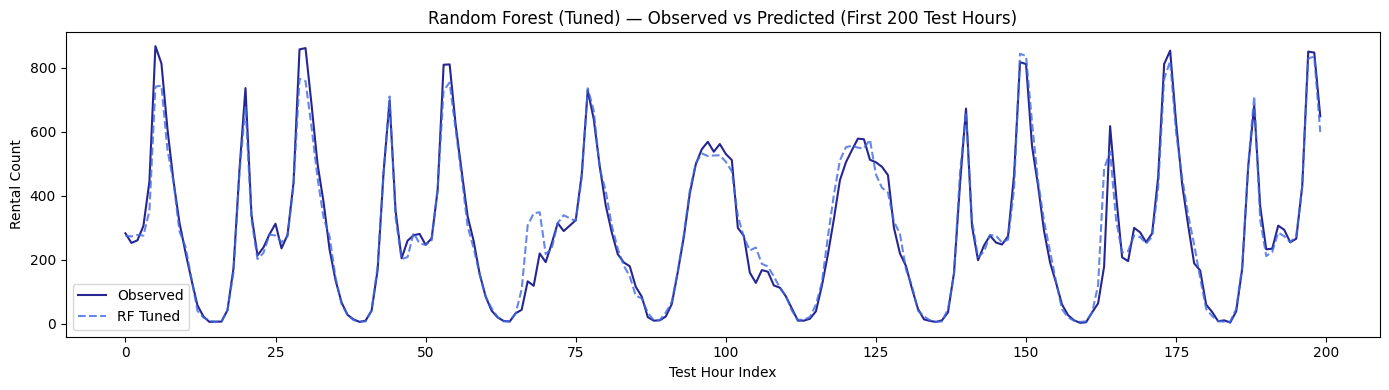

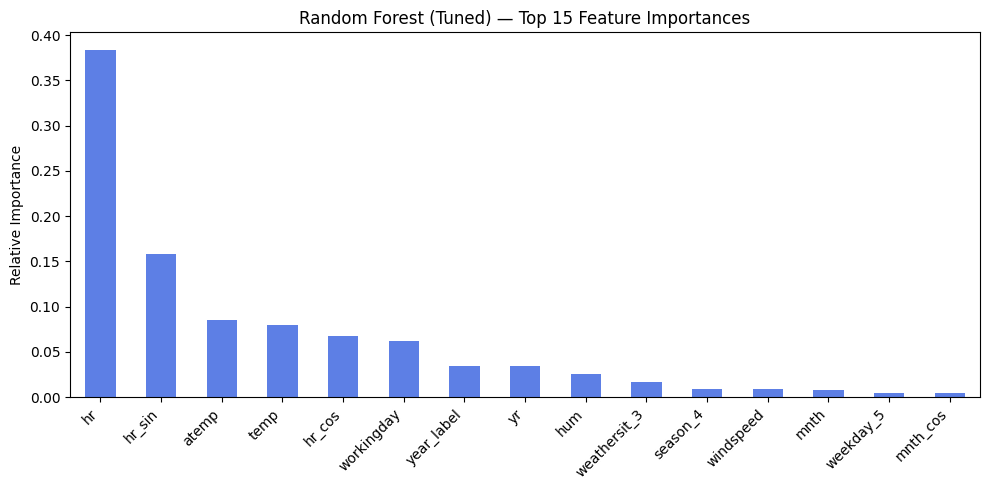

In [ ]:
fig_rft, ax_rft = plt.subplots(figsize=(14, 4))
ax_rft.plot(y_rft_te.values[:200], label="Observed", alpha=0.85, color='navy')
ax_rft.plot(yhat_rf_tuned[:200],   label="RF Tuned",  alpha=0.8,
            color='royalblue', linestyle='--')
ax_rft.set_title("Random Forest (Tuned) — Observed vs Predicted (First 200 Test Hours)")
ax_rft.set_xlabel("Test Hour Index")
ax_rft.set_ylabel("Rental Count")
ax_rft.legend()
plt.tight_layout()
plt.show()

fi_rf = pd.Series(
    best_forest.feature_importances_,
    index=X_rft_tr.columns
).sort_values(ascending=False).head(15)

fig_fi_rf, ax_fi_rf = plt.subplots(figsize=(10, 5))
fi_rf.plot(kind="bar", color="royalblue", alpha=0.85, ax=ax_fi_rf)
ax_fi_rf.set_title("Random Forest (Tuned) — Top 15 Feature Importances")
ax_fi_rf.set_ylabel("Relative Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.2 XGBoost — Tuned

In [ ]:
xgbt_data = bsd.copy()

xgbt_data["ts"] = pd.to_datetime(xgbt_data["dteday"]) + pd.to_timedelta(xgbt_data["hr"], unit="h")
xgbt_data = xgbt_data.sort_values("ts").reset_index(drop=True)

xgbt_data.drop(columns=["casual", "registered", "instant", "year_label"],
               errors="ignore", inplace=True)

xgbt_data["lag_1"]   = xgbt_data["cnt"].shift(1)
xgbt_data["lag_24"]  = xgbt_data["cnt"].shift(24)
xgbt_data["lag_168"] = xgbt_data["cnt"].shift(168)

xgbt_data.dropna(inplace=True)
xgbt_data.reset_index(drop=True, inplace=True)

xgbt_data["hr_sin"] = np.sin(2 * np.pi * xgbt_data["hr"] / 24)
xgbt_data["hr_cos"] = np.cos(2 * np.pi * xgbt_data["hr"] / 24)

xgbt_data = pd.get_dummies(xgbt_data,
                            columns=["season", "weathersit", "weekday"],
                            drop_first=True)

cut_xgbt = int(len(xgbt_data) * 0.8)
xgbt_tr  = xgbt_data.iloc[:cut_xgbt]
xgbt_te  = xgbt_data.iloc[cut_xgbt:]

X_xgbt_tr = xgbt_tr.drop(columns=["cnt", "dteday", "ts"])
y_xgbt_tr = xgbt_tr["cnt"]
X_xgbt_te = xgbt_te.drop(columns=["cnt", "dteday", "ts"])
y_xgbt_te = xgbt_te["cnt"]

ts_cv2 = TimeSeriesSplit(n_splits=5)

xgb_search_space = {
    "n_estimators":    [200, 400, 600, 800],
    "learning_rate":   [0.01, 0.03, 0.05, 0.1],
    "max_depth":       [3, 5, 7, 9],
    "subsample":       [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":[0.7, 0.8, 0.9, 1.0],
    "min_child_weight":[1, 3, 5],
    "gamma":           [0, 0.1, 0.3],
    "reg_alpha":       [0, 0.01, 0.1],
    "reg_lambda":      [1, 1.5, 2]
}

xgb_searcher = RandomizedSearchCV(
    estimator=XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
    param_distributions=xgb_search_space,
    n_iter=25,
    cv=ts_cv2,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)
xgb_searcher.fit(X_xgbt_tr, y_xgbt_tr)

best_boost     = xgb_searcher.best_estimator_
yhat_xgb_tuned = best_boost.predict(X_xgbt_te)

xgbt_rmse = np.sqrt(mean_squared_error(y_xgbt_te, yhat_xgb_tuned))
xgbt_mae  = mean_absolute_error(y_xgbt_te, yhat_xgb_tuned)
xgbt_r2   = r2_score(y_xgbt_te, yhat_xgb_tuned)
xgbt_mape = np.mean(np.abs((y_xgbt_te - yhat_xgb_tuned) / np.maximum(y_xgbt_te, 1))) * 100

print("Best XGBoost Hyperparameters:", xgb_searcher.best_params_)
print()
print("=== Tuned XGBoost — Evaluation ===")
print(f"RMSE : {xgbt_rmse:.2f}")
print(f"MAE  : {xgbt_mae:.2f}")
print(f"R²   : {xgbt_r2:.4f}")
print(f"MAPE : {xgbt_mape:.2f}%")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGBoost Hyperparameters: {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}

=== Tuned XGBoost — Evaluation ===
RMSE : 46.13
MAE  : 29.84
R²   : 0.9560
MAPE : 29.38%


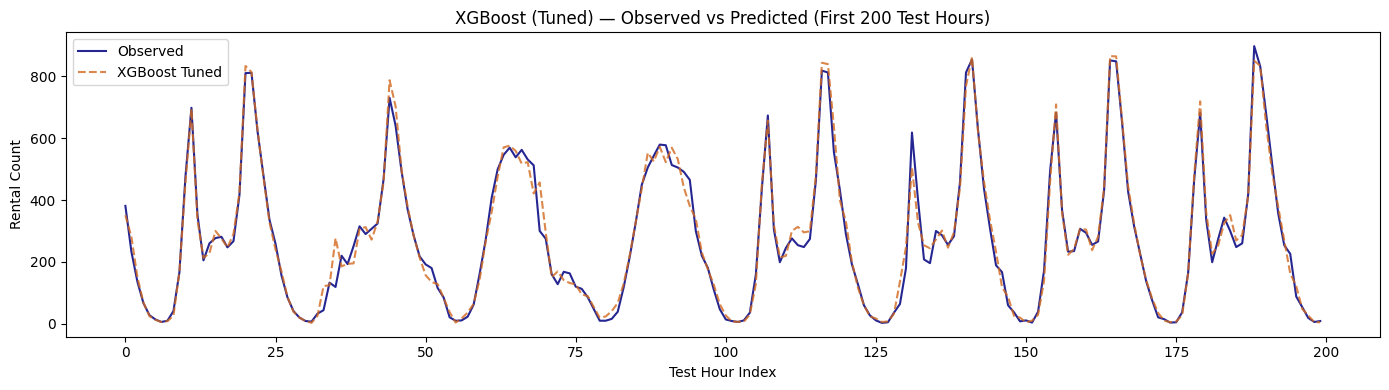

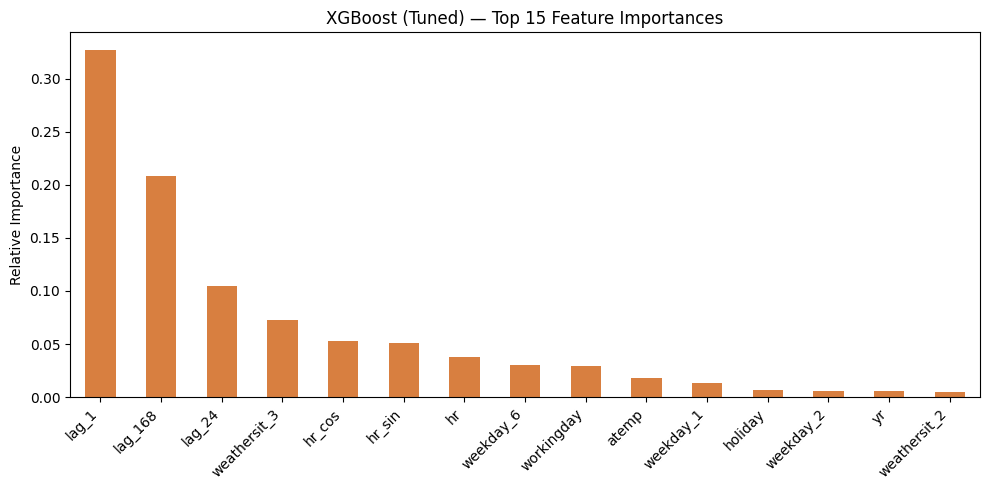

In [ ]:
fig_xgbt, ax_xgbt = plt.subplots(figsize=(14, 4))
ax_xgbt.plot(y_xgbt_te.values[:200], label="Observed", alpha=0.85, color='navy')
ax_xgbt.plot(yhat_xgb_tuned[:200],   label="XGBoost Tuned", alpha=0.8,
             color='chocolate', linestyle='--')
ax_xgbt.set_title("XGBoost (Tuned) — Observed vs Predicted (First 200 Test Hours)")
ax_xgbt.set_xlabel("Test Hour Index")
ax_xgbt.set_ylabel("Rental Count")
ax_xgbt.legend()
plt.tight_layout()
plt.show()

fi_xgb = pd.Series(
    best_boost.feature_importances_,
    index=X_xgbt_tr.columns
).sort_values(ascending=False).head(15)

fig_fi_xgb, ax_fi_xgb = plt.subplots(figsize=(10, 5))
fi_xgb.plot(kind="bar", color="chocolate", alpha=0.85, ax=ax_fi_xgb)
ax_fi_xgb.set_title("XGBoost (Tuned) — Top 15 Feature Importances")
ax_fi_xgb.set_ylabel("Relative Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.3 SARIMAX — Tuned (auto_arima)
`auto_arima` performs a stepwise AIC-guided order search on a computational subset (last 3,000 training rows).  
The chosen order is then re-estimated on the complete training set for the final forecast.

In [ ]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

def report_metrics(label, rmse, mae, r2, mape):
    divider = "=" * 48
    print(f"\n{divider}")
    print(f"  Model : {label}")
    print(divider)
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  R²    : {r2:.4f}")
    print(f"  MAPE  : {mape:.4f} %")

EXOG_FEATURES = ["hr_sin", "hr_cos", "mnth_sin", "mnth_cos",
                 "temp", "hum", "windspeed", "workingday", "weathersit"]

sar_tuned_data = bsd.copy()
sar_tuned_data.drop(columns=["casual", "registered", "instant", "year_label"],
                    errors="ignore", inplace=True)
sar_tuned_data["hr_sin"]   = np.sin(2 * np.pi * sar_tuned_data["hr"]   / 24)
sar_tuned_data["hr_cos"]   = np.cos(2 * np.pi * sar_tuned_data["hr"]   / 24)
sar_tuned_data["mnth_sin"] = np.sin(2 * np.pi * sar_tuned_data["mnth"] / 12)
sar_tuned_data["mnth_cos"] = np.cos(2 * np.pi * sar_tuned_data["mnth"] / 12)
sar_tuned_data = sar_tuned_data.sort_values(["dteday", "hr"]).reset_index(drop=True)

cut_st  = int(len(sar_tuned_data) * 0.8)
st_tr   = sar_tuned_data.iloc[:cut_st]
st_te   = sar_tuned_data.iloc[cut_st:]

X_st_tr = st_tr[EXOG_FEATURES].astype(float)
y_st_tr = st_tr["cnt"].astype(float)
X_st_te = st_te[EXOG_FEATURES].astype(float)
y_st_te = st_te["cnt"].astype(float)

SUBSET_N  = 3000
y_sub_st  = y_st_tr.iloc[-SUBSET_N:].reset_index(drop=True)
X_sub_st  = X_st_tr.iloc[-SUBSET_N:].reset_index(drop=True)

print("Initiating stepwise auto_arima order selection …")
arima_search = auto_arima(
    y_sub_st, X=X_sub_st,
    seasonal=True, m=24,
    stepwise=True, information_criterion="aic",
    d=0, D=0, max_p=2, max_q=2, max_P=1, max_Q=1,
    enforce_stationarity=False, enforce_invertibility=False,
    trace=True, error_action="ignore", suppress_warnings=True
)
print(f"\nSelected order : {arima_search.order}   Seasonal order : {arima_search.seasonal_order}")

Initiating stepwise auto_arima order selection …
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=34784.349, Time=103.31 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=38734.571, Time=3.87 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=35103.429, Time=62.72 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=35594.781, Time=50.04 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=38851.079, Time=2.65 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=35026.097, Time=67.98 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=34703.818, Time=76.37 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=36008.451, Time=14.62 sec
 ARIMA(1,0,2)(1,0,0)[24] intercept   : AIC=34692.412, Time=66.39 sec
 ARIMA(1,0,2)(0,0,0)[24] intercept   : AIC=36078.244, Time=12.99 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=77.47 sec
 ARIMA(1,0,2)(0,0,1)[24] intercept   : AIC=35019.341, Time=73.49 sec
 ARIMA(0,0,2)(1,0,0)[24] intercept   : AIC=34778.388, Time=49.12 sec
 ARIMA(1,0,1)(1,0,

In [ ]:
print("\nRefitting SARIMAX on complete training data …")
tuned_sarimax = SARIMAX(
    y_st_tr,
    exog=X_st_tr,
    order=arima_search.order,
    seasonal_order=arima_search.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

yhat_sar_tuned = tuned_sarimax.predict(
    start=len(y_st_tr),
    end=len(y_st_tr) + len(y_st_te) - 1,
    exog=X_st_te
).reset_index(drop=True)

y_st_te_plot = y_st_te.reset_index(drop=True)

sart_rmse = np.sqrt(mean_squared_error(y_st_te_plot, yhat_sar_tuned))
sart_mae  = mean_absolute_error(y_st_te_plot, yhat_sar_tuned)
sart_r2   = r2_score(y_st_te_plot, yhat_sar_tuned)
sart_mape = np.mean(np.abs((y_st_te_plot - yhat_sar_tuned) / y_st_te_plot)) * 100

report_metrics("SARIMAX — Tuned (auto_arima)", sart_rmse, sart_mae, sart_r2, sart_mape)
print(f"  AIC   : {tuned_sarimax.aic:.2f}")


Refitting SARIMAX on complete training data …


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  Model : SARIMAX — Tuned (auto_arima)
  RMSE  : 192.7760
  MAE   : 124.4135
  R²    : 0.2356
  MAPE  : 129.6344 %
  AIC   : 152653.59


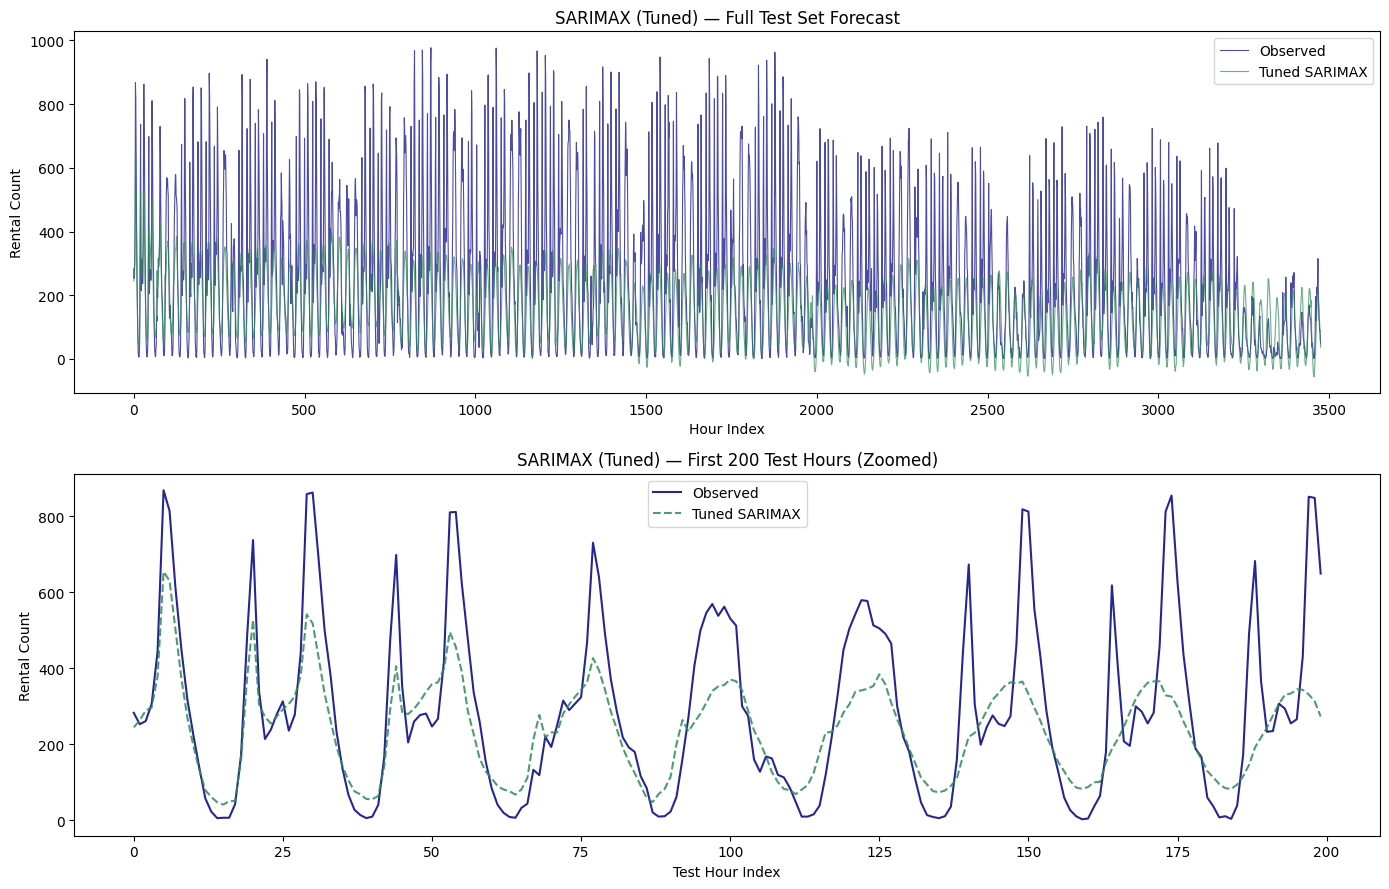

In [ ]:
fig_sart, ax_sart = plt.subplots(2, 1, figsize=(14, 9))

ax_sart[0].plot(y_st_te_plot.values, label="Observed", alpha=0.7, linewidth=0.8, color='navy')
ax_sart[0].plot(yhat_sar_tuned.values, label="Tuned SARIMAX", alpha=0.7, linewidth=0.8, color='seagreen')
ax_sart[0].set_title("SARIMAX (Tuned) — Full Test Set Forecast")
ax_sart[0].set_xlabel("Hour Index")
ax_sart[0].set_ylabel("Rental Count")
ax_sart[0].legend()

ax_sart[1].plot(y_st_te_plot.values[:200], label="Observed", alpha=0.85, color='navy')
ax_sart[1].plot(yhat_sar_tuned.values[:200], label="Tuned SARIMAX", alpha=0.85,
                color='seagreen', linestyle='--')
ax_sart[1].set_title("SARIMAX (Tuned) — First 200 Test Hours (Zoomed)")
ax_sart[1].set_xlabel("Test Hour Index")
ax_sart[1].set_ylabel("Rental Count")
ax_sart[1].legend()

plt.tight_layout()
plt.show()